# Modelos de Deep Learning: Aplicaciones prácticas

# **Tarea 1**



---
# PROBLEMA 1
## Clasificador lineal en TensorFlow

**Modificaciones solicitadas:**
1. Cambiar color del conjunto superior a verde y del inferior a rojo
2. Cambiar matriz de covarianza para que las nubes sean casi esféricas
3. Dibujar línea de decisión negra discontinua en lugar de roja

**Generando dos clases de puntos aleatorios en un plano 2D**

In [176]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

num_samples_per_class = 1000
# Matriz de covarianza casi esférica: valores pequeños en la diagonal, casi cero fuera
cov_esferica = [[0.2, 0.01], [0.01, 0.2]]
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=cov_esferica, size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=cov_esferica, size=num_samples_per_class)

**Apilando las dos clases en un array con forma (2000, 2)**

In [177]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [178]:
inputs.shape

(2000, 2)

**Generando los targets correspondientes (0 y 1)**

In [179]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

**Graficando las dos clases de puntos - Conjunto inferior (0) en ROJO, superior (1) en VERDE**

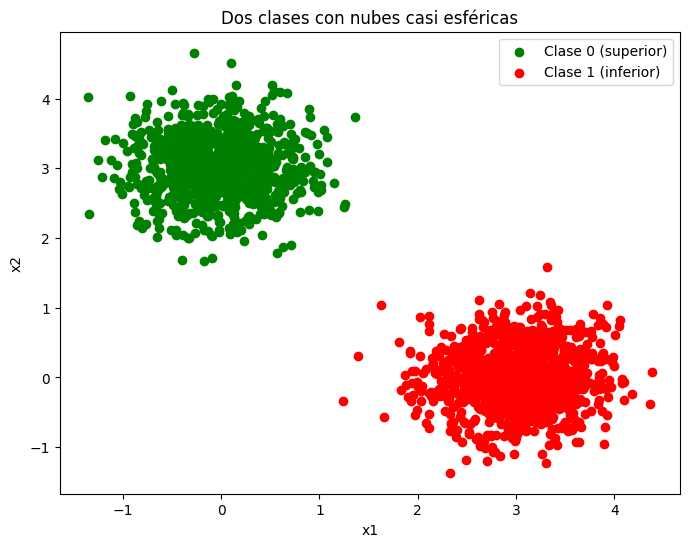

In [180]:
plt.figure(figsize=(8, 6))
mask0 = (targets[:, 0] == 0).flatten()
mask1 = (targets[:, 0] == 1).flatten()
plt.scatter(inputs[mask0, 0], inputs[mask0, 1], c='green', label='Clase 0 (superior)')
plt.scatter(inputs[mask1, 0], inputs[mask1, 1], c='red', label='Clase 1 (inferior)')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dos clases con nubes casi esféricas')
plt.show()

**Creando las variables del clasificador lineal**

In [181]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

**Función de forward pass**

In [182]:
def model(inputs):
    return tf.matmul(inputs, W) + b

**Función de pérdida (error cuadrático medio)**

In [183]:
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

**Función de paso de entrenamiento**

In [184]:
learning_rate = 0.1

def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(targets, predictions)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

**Ciclo de entrenamiento por lotes**

In [185]:
for step in range(40):
    loss = training_step(inputs, targets)
    if step % 10 == 0:
        print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 1.4824
Loss at step 10: 0.0296
Loss at step 20: 0.0270
Loss at step 30: 0.0247


**Graficando predicciones con LÍNEA DE DECISIÓN NEGRA DISCONTINUA**

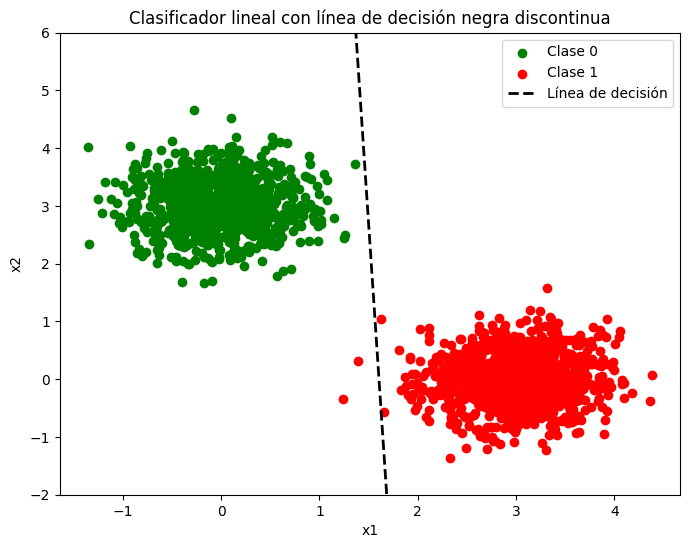

In [186]:
predictions = model(inputs)
w = W.numpy()
b_val = b.numpy()
x = np.linspace(-1, 4, 100)
y = -(w[0, 0] / w[1, 0]) * x + (0.5 - b_val[0]) / w[1, 0]

plt.figure(figsize=(8, 6))
mask0 = (targets[:, 0] == 0).flatten()
mask1 = (targets[:, 0] == 1).flatten()
plt.scatter(inputs[mask0, 0], inputs[mask0, 1], c='green', label='Clase 0')
plt.scatter(inputs[mask1, 0], inputs[mask1, 1], c='red', label='Clase 1')
plt.plot(x, y, 'k--', linewidth=2, label='Línea de decisión')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Clasificador lineal con línea de decisión negra discontinua')
plt.ylim(-2, 6)
plt.show()

---
# PROBLEMA 2
## Regresión lineal con tf.GradientTape()

Crear conjunto sintético de 100 puntos:
- x: rango [0, 10], distribución uniforme
- y: línea recta + ruido gaussiano (std=0.4)
- Resolver con descenso por gradiente usando tf.GradientTape()

In [187]:
np.random.seed(42)
tf.random.set_seed(42)

n_points = 100
# x: distribución uniforme en [0, 10]
x_data = np.random.uniform(0, 10, size=(n_points, 1)).astype(np.float32)
# y: línea recta (ej: y = 2x + 1) + ruido gaussiano std=0.2
pendiente_real = 2.0
intercepto_real = 1.0
y_data = (pendiente_real * x_data + intercepto_real +
          np.random.normal(0, 0.4, size=(n_points, 1))).astype(np.float32)

In [188]:
# Parámetros entrenables
w_reg = tf.Variable(tf.random.uniform(shape=(1, 1)))
b_reg = tf.Variable(tf.zeros(shape=(1,)))

def regression_model(x):
    return tf.matmul(x, w_reg) + b_reg

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

learning_rate_reg = 0.01
epochs = 500

In [189]:
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = regression_model(x_data)
        loss = mse_loss(y_data, y_pred)
    gradients = tape.gradient(loss, [w_reg, b_reg])
    w_reg.assign_sub(gradients[0] * learning_rate_reg)
    b_reg.assign_sub(gradients[1] * learning_rate_reg)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.6f}")

Epoch 100, Loss: 0.199376
Epoch 200, Loss: 0.152172
Epoch 300, Loss: 0.136654
Epoch 400, Loss: 0.131552
Epoch 500, Loss: 0.129875


In [190]:
print(f"\nParámetros encontrados:")
print(f"  Pendiente: {w_reg.numpy()[0,0]:.4f} (real: {pendiente_real})")
print(f"  Intercepto: {b_reg.numpy()[0]:.4f} (real: {intercepto_real})")


Parámetros encontrados:
  Pendiente: 1.9898 (real: 2.0)
  Intercepto: 1.0325 (real: 1.0)


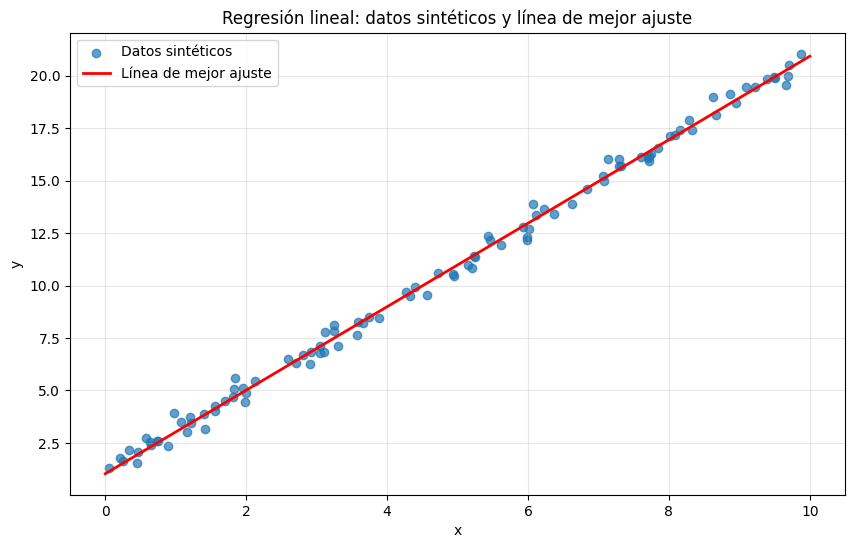

In [191]:
# Graficar puntos de datos y línea de mejor ajuste
x_plot = np.linspace(0, 10, 100).reshape(-1, 1).astype(np.float32)
y_plot = regression_model(x_plot).numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, alpha=0.7, label='Datos sintéticos')
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label='Línea de mejor ajuste')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión lineal: datos sintéticos y línea de mejor ajuste')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# PROBLEMA 3
## Red neuronal para clasificación binaria (Iris)

Revisión del cuaderno DL_Tarea_1_PartII - Implementación desde cero con NumPy

In [192]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

np.random.seed(42)

In [193]:
import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")

TensorFlow: 2.19.0
Keras: 3.13.2


In [194]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = (iris.target != 0) * 1

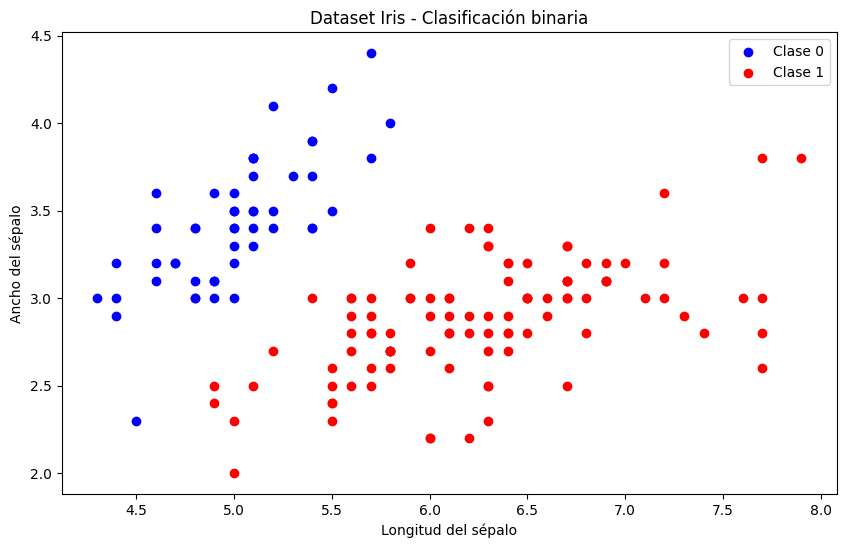

In [195]:
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='b', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', label='Clase 1')
plt.legend()
plt.xlabel('Longitud del sépalo')
plt.ylabel('Ancho del sépalo')
plt.title('Dataset Iris - Clasificación binaria')
plt.show()

In [196]:
X = X.T
y = y.reshape(1, 150)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2, 150)
y shape: (1, 150)


**Implementación de funciones: sigmoid, forward/backward propagation, y entrenamiento**

In [197]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def layer_sizes(X, Y):
    n_x = X.shape[0]
    n_h = 4
    n_y = Y.shape[0]
    return (n_x, n_h, n_y)

def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(2)
    W1 = 0.01 * np.random.randn(n_h, n_x)
    b1 = np.zeros((n_h, 1))
    W2 = 0.01 * np.random.randn(n_y, n_h)
    b2 = np.zeros((n_y, 1))
    return {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

def compute_cost(A2, Y, parameters):
    m = Y.shape[1]
    A2 = np.clip(A2, 1e-8, 1 - 1e-8)
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), 1 - Y)
    return -np.sum(logprobs) / m

def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1]
    W2 = parameters['W2']
    A1, A2 = cache['A1'], cache['A2']
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

def update_parameters(parameters, grads, learning_rate=1.2):
    parameters['W1'] -= learning_rate * grads['dW1']
    parameters['b1'] -= learning_rate * grads['db1']
    parameters['W2'] -= learning_rate * grads['dW2']
    parameters['b2'] -= learning_rate * grads['db2']
    return parameters

In [198]:
def nn_model(X, Y, n_h, lr=1.2, num_iterations=10000, print_cost=False):
    np.random.seed(3)
    n_x, _, n_y = layer_sizes(X, Y)
    parameters = initialize_parameters(n_x, n_h, n_y)
    for i in range(num_iterations):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y, parameters)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads, learning_rate=lr)
        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost:.4f}")
    return parameters

In [199]:
parameters = nn_model(X, y, n_h=4, lr=0.3, num_iterations=10000, print_cost=True)

Cost after iteration 0: 0.6930
Cost after iteration 1000: 0.0259
Cost after iteration 2000: 0.0156
Cost after iteration 3000: 0.0090
Cost after iteration 4000: 0.0059
Cost after iteration 5000: 0.0044
Cost after iteration 6000: 0.0034
Cost after iteration 7000: 0.0028
Cost after iteration 8000: 0.0023
Cost after iteration 9000: 0.0020


In [200]:
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    return (A2 > 0.5)

predictions = predict(parameters, X)
accuracy = np.mean((predictions == y).astype(float)) * 100
print(f"Precisión en entrenamiento: {accuracy:.2f}%")

Precisión en entrenamiento: 100.00%
